First five rows:
         Price  SquareFootage  NumBathrooms  NumBedrooms  BackyardSpace  \
0  176391.7665        1002.49             1            2         354.22   
1  402358.3158         897.55             5            3         579.57   
2  124287.4584         774.63             2            1        1114.67   
3  396428.1539         550.00             1            4         561.07   
4  208725.8216         614.91             2            2         782.71   

   CrimeRate  SchoolRating  AgeOfHome  DistanceToCityCenter  EmploymentRate  \
0      44.61             8     106.01                 26.79           94.32   
1      41.05             6      13.77                 24.40           86.13   
2      49.10             8      22.59                  8.74           99.90   
3      29.17             7     104.06                  2.94           94.05   
4      63.76             8      22.15                 15.01           99.90   

   PreviousSalePrice  
0        165208.5865  
1        52

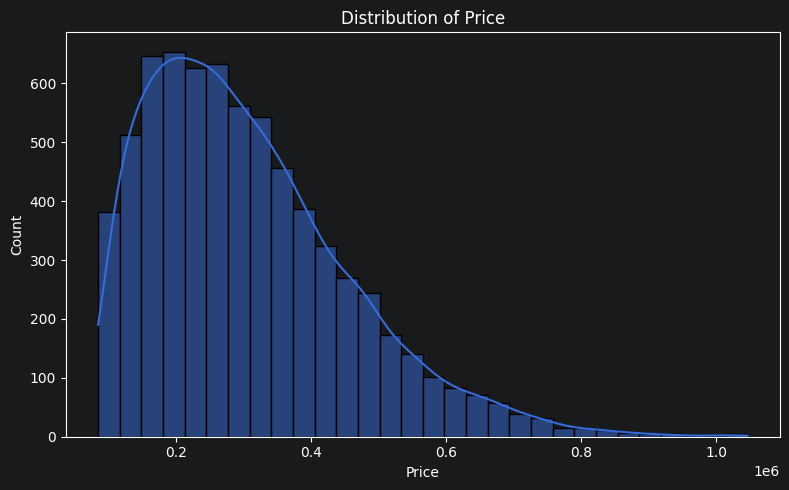

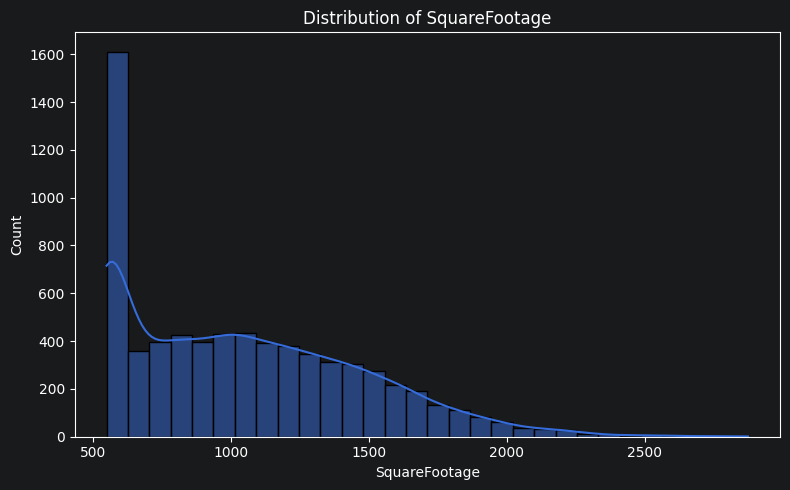

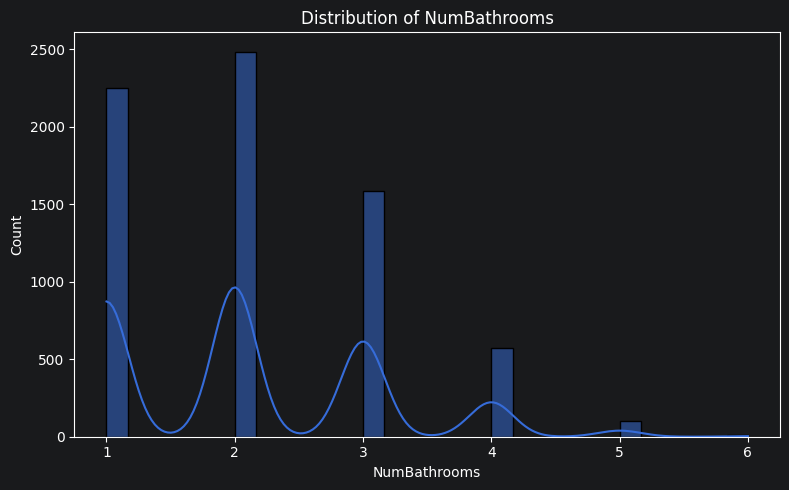

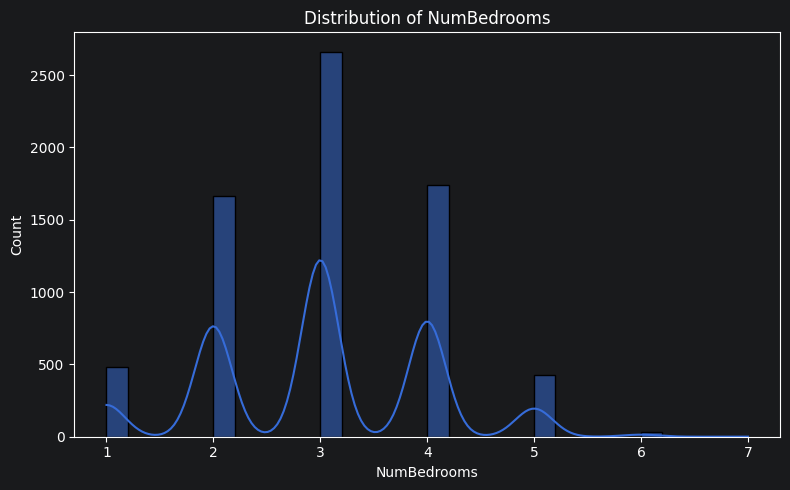

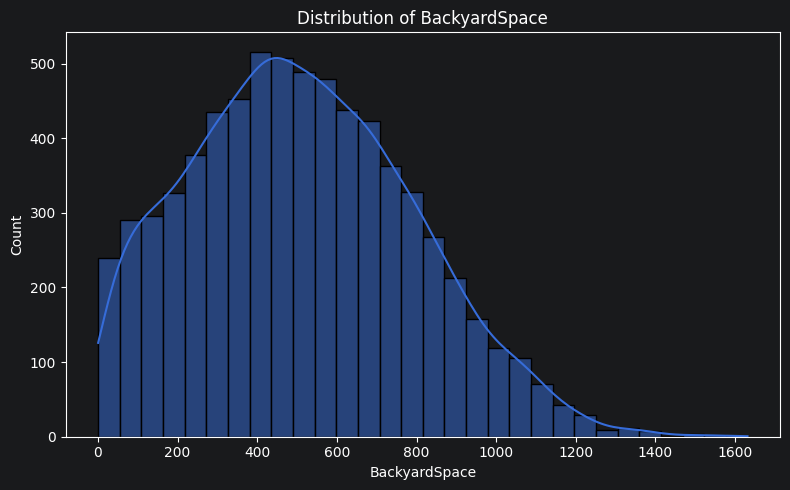

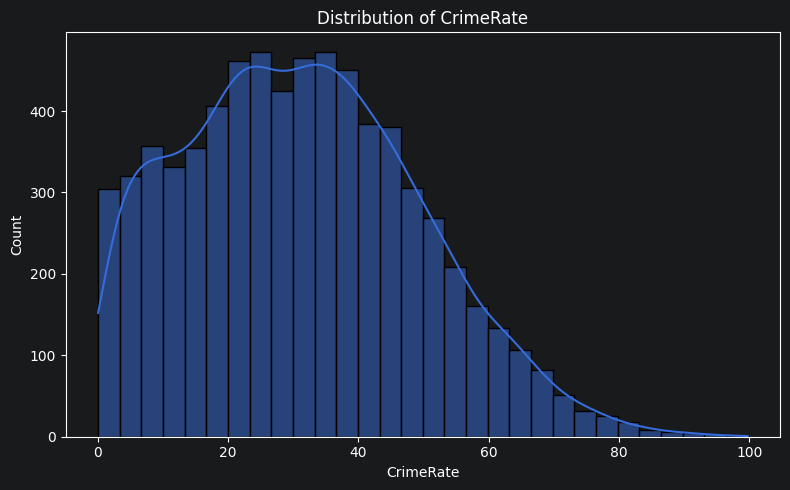

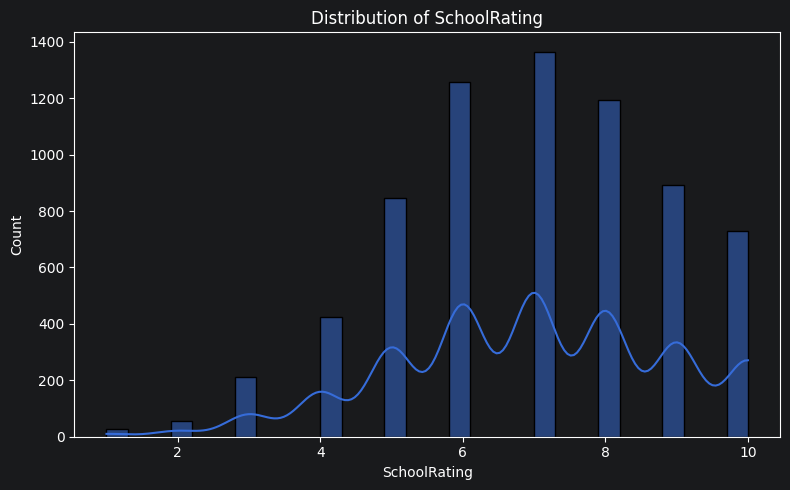

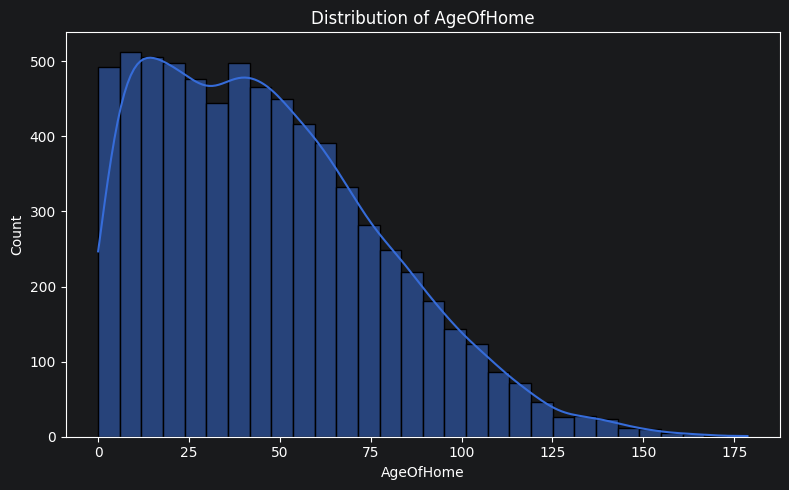

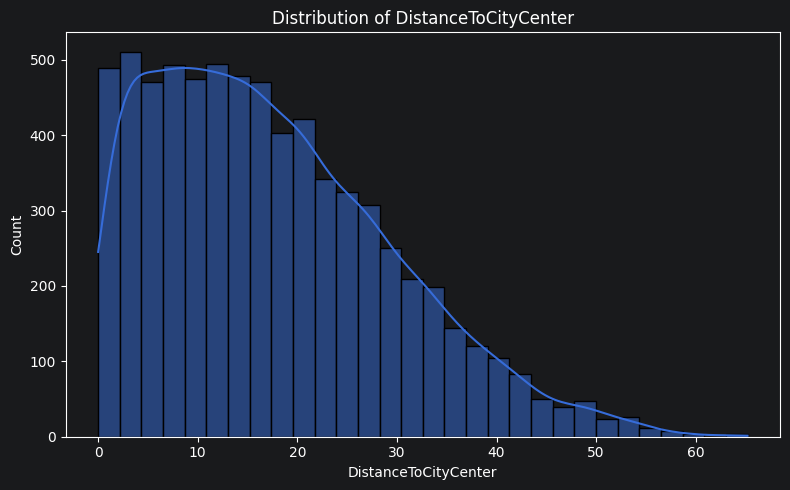

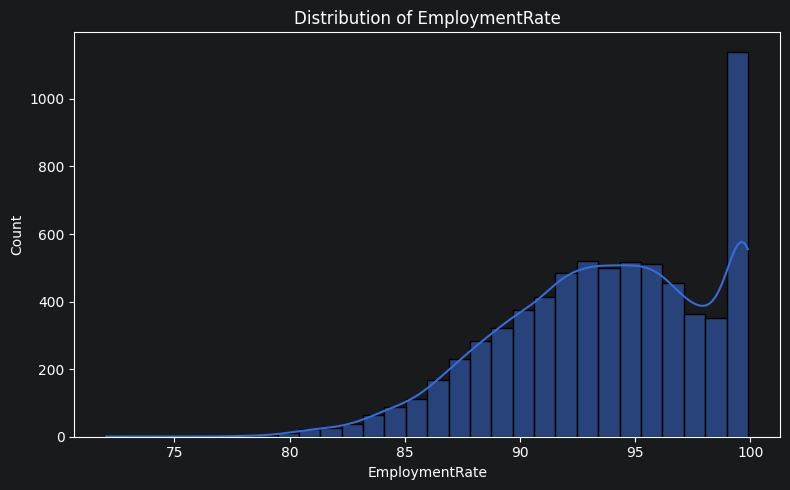

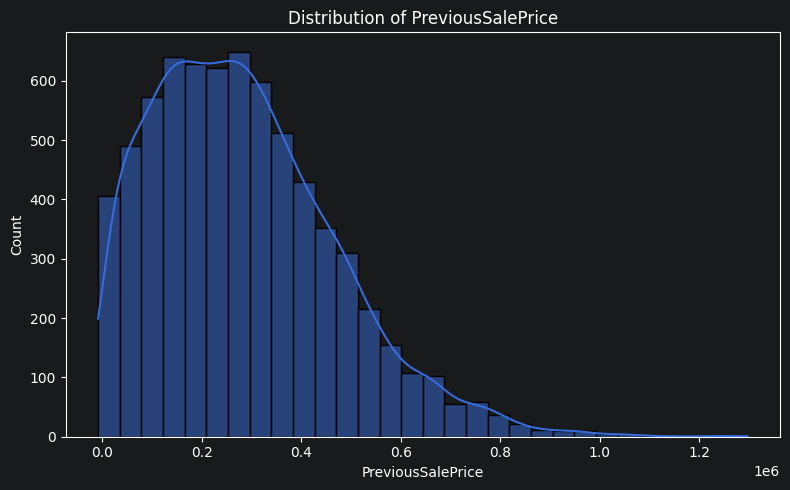

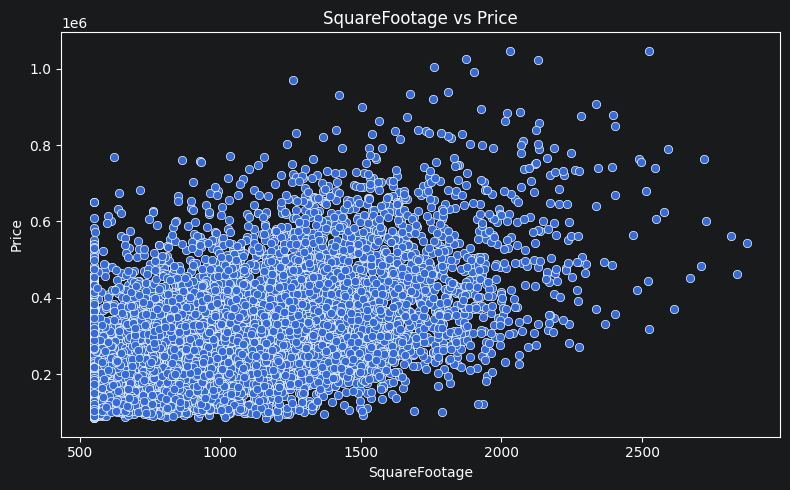

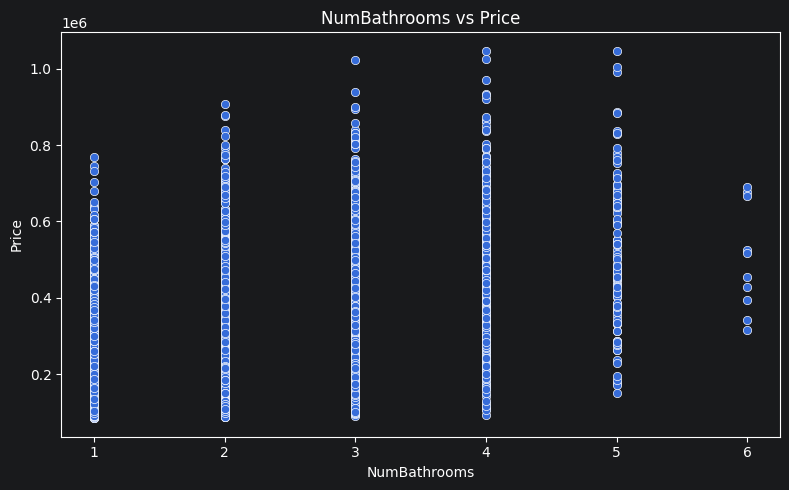

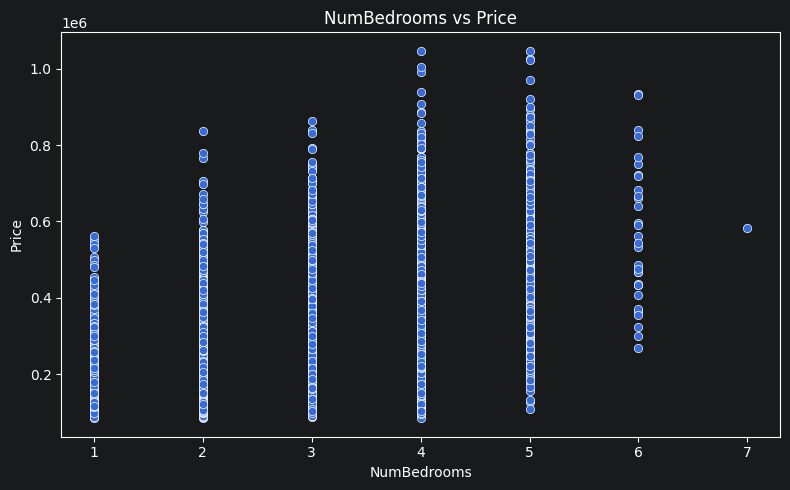

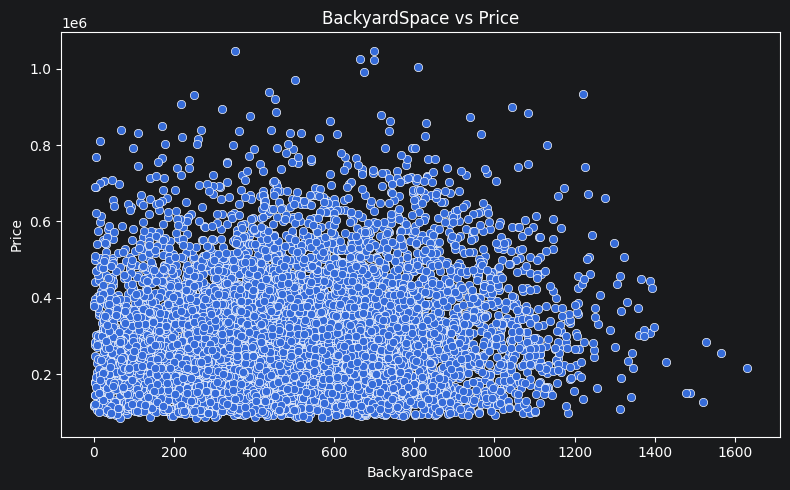

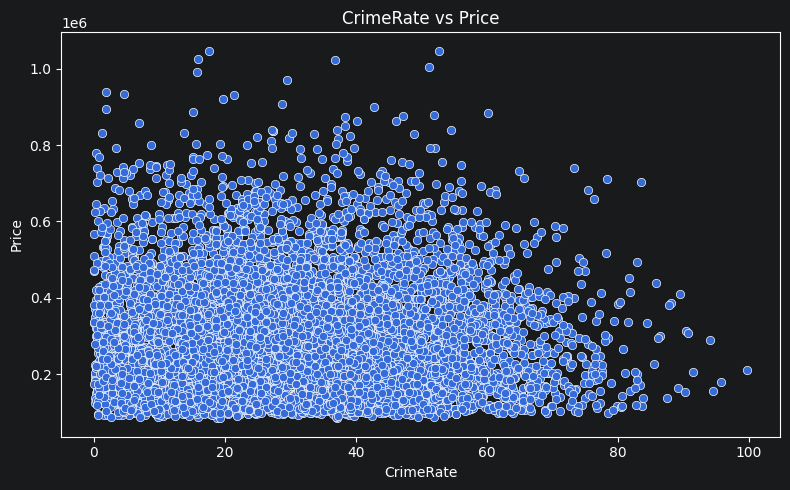

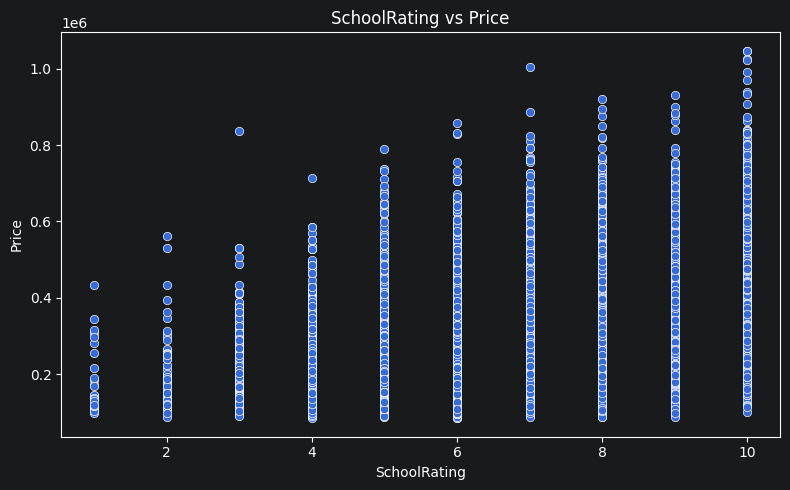

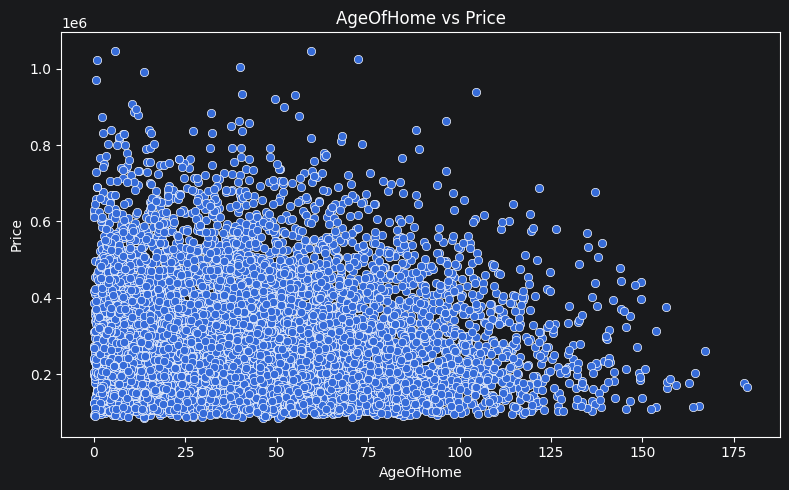

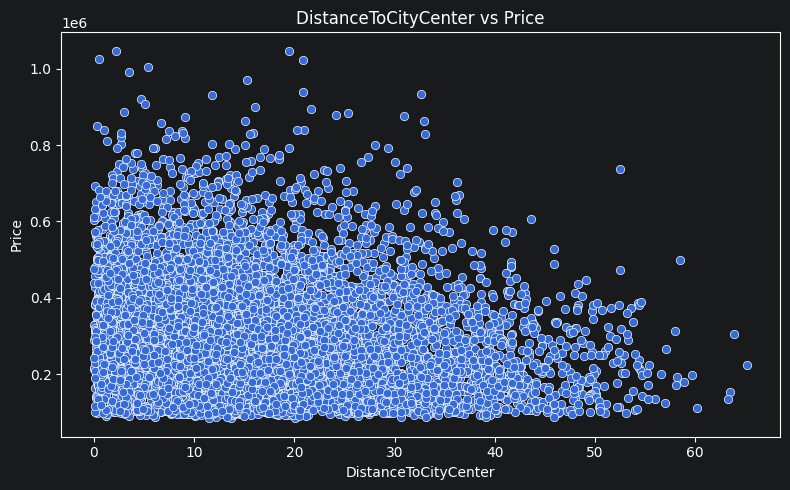

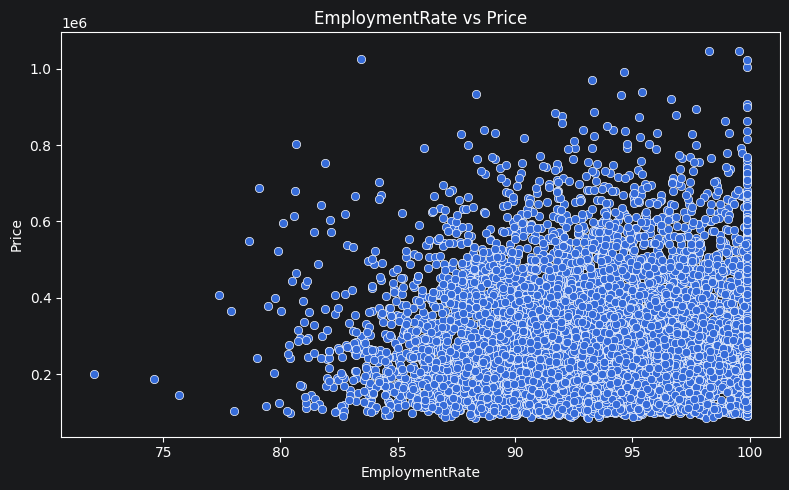

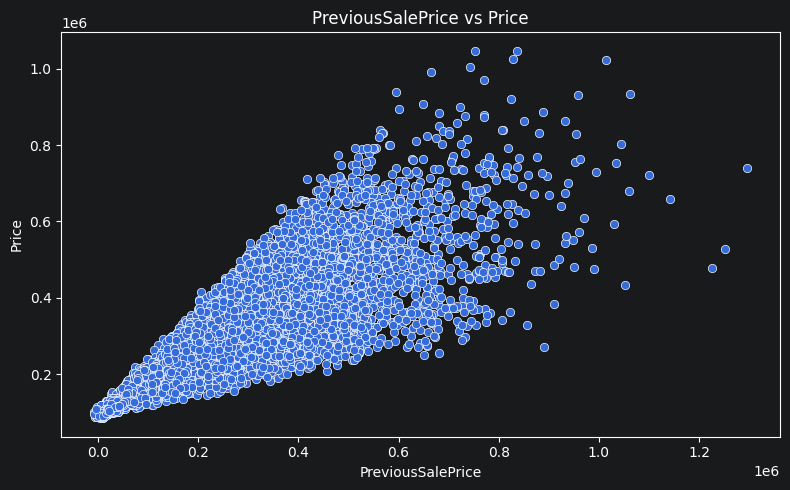


Missing Values:
Price                   0
SquareFootage           0
NumBathrooms            0
NumBedrooms             0
BackyardSpace           0
CrimeRate               0
SchoolRating            0
AgeOfHome               0
DistanceToCityCenter    0
EmploymentRate          0
PreviousSalePrice       0
dtype: int64

Checking for invalid or illogical values:
SquareFootage: 0 invalid values
NumBathrooms: 0 invalid values
NumBedrooms: 0 invalid values
BackyardSpace: 0 invalid values
CrimeRate: 0 invalid values
AgeOfHome: 0 invalid values
DistanceToCityCenter: 0 invalid values
EmploymentRate: 0 invalid values
PreviousSalePrice: 28 invalid values

Invalid values after correction:
PreviousSalePrice: 0 invalid values

Data Types:
Price                   float64
SquareFootage           float64
NumBathrooms              int64
NumBedrooms               int64
BackyardSpace           float64
CrimeRate               float64
SchoolRating              int64
AgeOfHome               float64
DistanceToCi

In [1]:
# D600 Task 1 - Multiple Linear Regression

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Load dataset
df = pd.read_csv(
    r"C:\Users\Alyss\Downloads\D600 Task 1, 2 and 3 Dataset Housing Information.csv"
)


# Variables selected in B1
selected_vars = [
    'Price',
    'SquareFootage',
    'NumBathrooms',
    'NumBedrooms',
    'BackyardSpace',
    'CrimeRate',
    'SchoolRating',
    'AgeOfHome',
    'DistanceToCityCenter',
    'EmploymentRate',
    'PreviousSalePrice'
]

# Create modeling dataset
df_model = df[selected_vars].copy()

print("First five rows:")
print(df_model.head())

print("\nSelected Variables:")
print(df_model.columns)

# -----------------------------
# B2 Descriptive Statistics
# -----------------------------
print("\nDescriptive Statistics:")
print(df_model.describe())

# -----------------------------
# B3 Univariate Visualizations
# -----------------------------
for column in selected_vars:
    plt.figure(figsize=(8,5))
    sns.histplot(df_model[column], bins=30, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# -----------------------------
# B3 Bivariate Visualizations
# -----------------------------
independent_vars = [
    'SquareFootage',
    'NumBathrooms',
    'NumBedrooms',
    'BackyardSpace',
    'CrimeRate',
    'SchoolRating',
    'AgeOfHome',
    'DistanceToCityCenter',
    'EmploymentRate',
    'PreviousSalePrice'
]

for column in independent_vars:
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        x=df_model[column],
        y=df_model["Price"]
    )
    plt.title(f"{column} vs Price")
    plt.xlabel(column)
    plt.ylabel("Price")
    plt.tight_layout()
    plt.show()

# -----------------------------
# B4 Data Cleaning
# -----------------------------

# Check for missing values
print("\nMissing Values:")
print(df_model.isnull().sum())

# Check for invalid or illogical values
print("\nChecking for invalid or illogical values:")

columns_to_check = [
    'SquareFootage',
    'NumBathrooms',
    'NumBedrooms',
    'BackyardSpace',
    'CrimeRate',
    'AgeOfHome',
    'DistanceToCityCenter',
    'EmploymentRate',
    'PreviousSalePrice'
]

for column in columns_to_check:
    invalid_count = (df_model[column] < 0).sum()
    print(f"{column}: {invalid_count} invalid values")

# Replace invalid PreviousSalePrice values with the median
median_previous_sale = df_model.loc[
    df_model['PreviousSalePrice'] >= 0,
    'PreviousSalePrice'
].median()

df_model.loc[
    df_model['PreviousSalePrice'] < 0,
    'PreviousSalePrice'
] = median_previous_sale

print("\nInvalid values after correction:")
print("PreviousSalePrice:",
      (df_model['PreviousSalePrice'] < 0).sum(),
      "invalid values")

# SchoolRating is already stored as an ordinal rating (1–10), so no encoding is required.

# Check data types
print("\nData Types:")
print(df_model.dtypes)

# Update the predictor list
independent_vars = [col for col in df_model.columns if col != 'Price']

# B4 outlier capping using IQR method
print("\nRows before outlier capping:", len(df_model))

# Cap outliers for Price
Q1 = df_model['Price'].quantile(0.25)
Q3 = df_model['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_model['Price'] = df_model['Price'].clip(lower=lower_bound, upper=upper_bound)
print("\nPrice")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Cap outliers for SquareFootage
Q1 = df_model['SquareFootage'].quantile(0.25)
Q3 = df_model['SquareFootage'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_model['SquareFootage'] = df_model['SquareFootage'].clip(lower=lower_bound, upper=upper_bound)
print("\nSquareFootage")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Cap outliers for NumBathrooms
Q1 = df_model['NumBathrooms'].quantile(0.25)
Q3 = df_model['NumBathrooms'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_model['NumBathrooms'] = df_model['NumBathrooms'].clip(lower=lower_bound, upper=upper_bound)
print("\nNumBathrooms")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Cap outliers for NumBedrooms
Q1 = df_model['NumBedrooms'].quantile(0.25)
Q3 = df_model['NumBedrooms'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_model['NumBedrooms'] = df_model['NumBedrooms'].clip(lower=lower_bound, upper=upper_bound)
print("\nNumBedrooms")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Cap outliers for BackyardSpace
Q1 = df_model['BackyardSpace'].quantile(0.25)
Q3 = df_model['BackyardSpace'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_model['BackyardSpace'] = df_model['BackyardSpace'].clip(lower=lower_bound, upper=upper_bound)
print("\nBackyardSpace")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Cap outliers for CrimeRate
Q1 = df_model['CrimeRate'].quantile(0.25)
Q3 = df_model['CrimeRate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_model['CrimeRate'] = df_model['CrimeRate'].clip(lower=lower_bound, upper=upper_bound)
print("\nCrimeRate")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)


# Cap outliers for AgeOfHome
Q1 = df_model['AgeOfHome'].quantile(0.25)
Q3 = df_model['AgeOfHome'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_model['AgeOfHome'] = df_model['AgeOfHome'].clip(lower=lower_bound, upper=upper_bound)
print("\nAgeOfHome")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Cap outliers for DistanceToCityCenter
Q1 = df_model['DistanceToCityCenter'].quantile(0.25)
Q3 = df_model['DistanceToCityCenter'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_model['DistanceToCityCenter'] = df_model['DistanceToCityCenter'].clip(lower=lower_bound, upper=upper_bound)
print("\nDistanceToCityCenter")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Cap outliers for EmploymentRate
Q1 = df_model['EmploymentRate'].quantile(0.25)
Q3 = df_model['EmploymentRate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_model['EmploymentRate'] = df_model['EmploymentRate'].clip(lower=lower_bound, upper=upper_bound)
print("\nEmploymentRate")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Cap outliers for PreviousSalePrice
Q1 = df_model['PreviousSalePrice'].quantile(0.25)
Q3 = df_model['PreviousSalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_model['PreviousSalePrice'] = df_model['PreviousSalePrice'].clip(lower=lower_bound, upper=upper_bound)
print("\nPreviousSalePrice")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nRows after outlier capping:", len(df_model))

# Show cleaned dataset
print("\nCleaned dataset preview:")
print(df_model.head())

# Define independent variables and dependent variable
X = df_model[independent_vars]
y = df_model['Price']

# Split dataset into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining and testing dataset sizes:")
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

# Initial multiple linear regression model
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const).fit()

print("\nInitial Multiple Linear Regression Model Summary:")
print(model.summary())

X_train_optimized = X_train[
    [
        'SquareFootage',
        'NumBathrooms',
        'NumBedrooms',
        'DistanceToCityCenter',
        'PreviousSalePrice'
    ]
]

# Optimized multiple linear regression model
X_train_optimized_const = sm.add_constant(X_train_optimized)
optimized_model = sm.OLS(y_train, X_train_optimized_const).fit()

print("\nOptimized Multiple Linear Regression Model Summary:")
print(optimized_model.summary())

# Prediction on test dataset using optimized variables
X_test_optimized = X_test[
    [
        'SquareFootage',
        'NumBathrooms',
        'NumBedrooms',
        'DistanceToCityCenter',
        'PreviousSalePrice'
    ]
]

X_test_optimized_const = sm.add_constant(X_test_optimized)
predictions = optimized_model.predict(X_test_optimized_const)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("\nRMSE:", rmse)

# Export datasets
df_model.to_csv("cleaned_dataset.csv", index=False)
X_train.to_csv("training_dataset.csv", index=False)
X_test.to_csv("testing_dataset.csv", index=False)
